# Hand-drawn Digit Image Generation with GAN

### Presented by:
- **Name**: Abhinav Singh (22UCS004)
- **Name**: Yash Gupta (22UCS234)

## Project Overview

### Purpose
Develop a Generative Adversarial Network (GAN) to generate realistic digit images, leveraging the competitive training of a generator and discriminator.

### Goals
- Train a GAN to generate synthetic digit images resembling the MNIST dataset.
- Evaluate generated images using visual and quantitative metrics.
- Showcase GANs' potential in generating realistic synthetic data.

### Significance
GANs have transformed AI by enabling realistic data generation, with applications in data augmentation, creative design, and beyond.

#### PyTorch Setup Instructions
This notebook was trained on **PyTorch version 2.6.0+cu126 with CUDA 12.6** as the platform. To ensure this works correctly on your system, please run the following commands in the kernel terminal where you are running this notebook:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
pip install jupyter matplotlib numpy
```

### Import Necessary Libraries

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

#### Check CUDA Availability

In [2]:
print(f"Pytorch Version: {torch.__version__}")
print(f"Cuda version: {torch.version.cuda}")
print(f"Is CUDA version availaible: {torch.cuda.is_available()}")

# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Pytorch Version: 2.6.0+cu126
Cuda version: 12.6
Is CUDA version availaible: True
Using device: cuda


#### Hyperparameters

In [3]:

# Hyperparameters
batch_size = 128
latent_dim = 150
lr = 0.0004
epochs = 400


### Dataset Description

#### Source
The MNIST dataset, a benchmark in machine learning, contains grayscale images of handwritten digits (0-9). It is publicly available via sources like the `torchvision` library.

#### Size
- **Training set**: 60,000 images  
- **Test set**: 10,000 images  
Each image is 28x28 pixels, grayscale.

#### Preprocessing
1. **Normalization**: Scaled pixel values to [0, 1] for better training convergence.  
2. **Reshaping**: Adjusted image dimensions to match GAN input requirements.  
3. **Data Loading**: Used `torch.utils.data.DataLoader` for efficient batch processing.



In [4]:

# Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True
)



## Model Architecture

### Overview
The Generative Adversarial Network (GAN) consists of two components:
1. **Generator**: Generates synthetic digit images from random noise.
2. **Discriminator**: Distinguishes between real and synthetic images.

These networks are trained simultaneously in a competitive setting: the generator aims to produce realistic images, while the discriminator learns to classify images as real or fake.

---
 
### Generator Architecture
The generator maps random noise vectors to realistic digit images using transposed convolutional layers.

- **Input**: Random noise vector (size 100).
- **Layers**:
  - Fully connected layer to reshape noise into a feature map.
  - Transposed convolutional layers with ReLU activations for upsampling.
  - Batch normalization layers for training stability.
  - Final transposed convolutional layer with Tanh activation to generate the output image.
- **Output**: 28x28 grayscale image.

---

### Discriminator Architecture
The discriminator is a convolutional neural network (CNN) that classifies images as real or fake.

- **Input**: 28x28 grayscale image.
- **Layers**:
  - Convolutional layers with LeakyReLU activations for feature extraction.
  - Dropout layers to prevent overfitting.
  - Fully connected layer to output a single probability value.
- **Output**: Scalar value representing the probability of the image being real.

---

### Key Components
- **LeakyReLU Activation**: Used in the discriminator for better gradient flow.
- **Tanh Activation**: Scales generator outputs to [-1, 1], matching normalized dataset values.
- **Batch Normalization**: Stabilizes training and improves convergence in the generator.

---



In [5]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_embedding = self.label_emb(labels)
        x = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(x)

In [6]:
# Define the Generator (should be ConditionalGenerator)
class ConditionalGenerator(nn.Module):  # Changed from Generator
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([z, label_embedding], dim=1)
        return self.model(x).view(-1, 1, 28, 28)

# Define parameters
latent_dim = 100
num_classes = 10  # For MNIST digits 0-9

# Initialize models WITH CORRECT CLASS NAMES AND PARAMETERS
generator = ConditionalGenerator(latent_dim, num_classes).to(device)  # Changed here
discriminator = ConditionalDiscriminator(num_classes).to(device)  # Changed here

# Optimizers (keep same)
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

[Epoch 1/400] D_loss: 0.0507 G_loss: 48.7768
[Epoch 2/400] D_loss: 0.0757 G_loss: 21.4031
[Epoch 3/400] D_loss: 0.0313 G_loss: 30.4489
[Epoch 4/400] D_loss: 0.0281 G_loss: 19.5298
[Epoch 5/400] D_loss: 0.0025 G_loss: 40.4374
[Epoch 6/400] D_loss: 0.0296 G_loss: 32.2333
[Epoch 7/400] D_loss: 0.0048 G_loss: 21.5394
[Epoch 8/400] D_loss: 0.0755 G_loss: 15.6601
[Epoch 9/400] D_loss: 0.0130 G_loss: 30.6777
[Epoch 10/400] D_loss: 0.0135 G_loss: 45.2662
[Epoch 11/400] D_loss: 0.0528 G_loss: 24.5233
[Epoch 12/400] D_loss: 0.0018 G_loss: 21.4219
[Epoch 13/400] D_loss: 0.0398 G_loss: 26.8306
[Epoch 14/400] D_loss: 0.0553 G_loss: 23.7191
[Epoch 15/400] D_loss: 0.0641 G_loss: 49.6762
[Epoch 16/400] D_loss: 0.0315 G_loss: 20.1053
[Epoch 17/400] D_loss: 0.0274 G_loss: 24.4586
[Epoch 18/400] D_loss: 0.1077 G_loss: 22.5535
[Epoch 19/400] D_loss: 0.0905 G_loss: 14.2672
[Epoch 20/400] D_loss: 0.4515 G_loss: 18.0760
[Epoch 21/400] D_loss: 0.4231 G_loss: 11.4634
[Epoch 22/400] D_loss: 0.6922 G_loss: 13.65

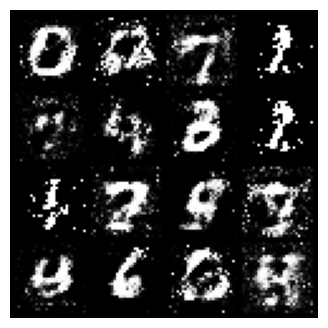

[Epoch 51/400] D_loss: 0.6798 G_loss: 2.0879
[Epoch 52/400] D_loss: 0.8062 G_loss: 2.2367
[Epoch 53/400] D_loss: 0.7407 G_loss: 1.7566
[Epoch 54/400] D_loss: 0.8484 G_loss: 1.9816
[Epoch 55/400] D_loss: 0.7881 G_loss: 1.8235
[Epoch 56/400] D_loss: 0.9516 G_loss: 1.4888
[Epoch 57/400] D_loss: 0.9072 G_loss: 1.7090
[Epoch 58/400] D_loss: 0.8802 G_loss: 1.6238
[Epoch 59/400] D_loss: 0.9529 G_loss: 1.6327
[Epoch 60/400] D_loss: 0.9685 G_loss: 2.1056
[Epoch 61/400] D_loss: 0.9875 G_loss: 1.7439
[Epoch 62/400] D_loss: 0.8982 G_loss: 1.5862
[Epoch 63/400] D_loss: 0.9722 G_loss: 1.5324
[Epoch 64/400] D_loss: 0.8620 G_loss: 1.7254
[Epoch 65/400] D_loss: 1.0132 G_loss: 1.8290
[Epoch 66/400] D_loss: 0.9573 G_loss: 1.6426
[Epoch 67/400] D_loss: 0.9501 G_loss: 1.6621
[Epoch 68/400] D_loss: 0.8081 G_loss: 1.5957
[Epoch 69/400] D_loss: 0.9302 G_loss: 1.4826
[Epoch 70/400] D_loss: 1.1144 G_loss: 1.4970
[Epoch 71/400] D_loss: 1.1812 G_loss: 1.4860
[Epoch 72/400] D_loss: 0.9359 G_loss: 1.2096
[Epoch 73/

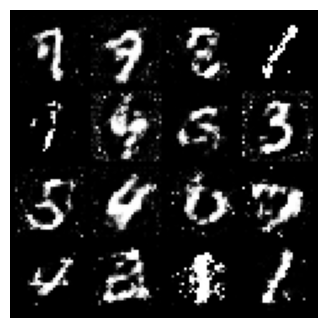

[Epoch 101/400] D_loss: 1.1620 G_loss: 1.1952
[Epoch 102/400] D_loss: 1.1424 G_loss: 0.9773
[Epoch 103/400] D_loss: 1.2054 G_loss: 1.0867
[Epoch 104/400] D_loss: 1.0200 G_loss: 1.2154
[Epoch 105/400] D_loss: 1.1191 G_loss: 1.3521
[Epoch 106/400] D_loss: 1.0534 G_loss: 1.3465
[Epoch 107/400] D_loss: 1.1273 G_loss: 1.3300
[Epoch 108/400] D_loss: 1.0657 G_loss: 1.2182
[Epoch 109/400] D_loss: 1.1706 G_loss: 1.2425
[Epoch 110/400] D_loss: 1.1300 G_loss: 1.1440
[Epoch 111/400] D_loss: 1.0797 G_loss: 1.2715
[Epoch 112/400] D_loss: 1.1753 G_loss: 1.3027
[Epoch 113/400] D_loss: 1.3872 G_loss: 1.0177
[Epoch 114/400] D_loss: 1.1613 G_loss: 1.1582
[Epoch 115/400] D_loss: 1.1162 G_loss: 1.0003
[Epoch 116/400] D_loss: 1.2597 G_loss: 0.9269
[Epoch 117/400] D_loss: 1.3008 G_loss: 0.9776
[Epoch 118/400] D_loss: 1.1765 G_loss: 1.2102
[Epoch 119/400] D_loss: 1.1517 G_loss: 0.9488
[Epoch 120/400] D_loss: 1.2091 G_loss: 1.0999
[Epoch 121/400] D_loss: 1.2603 G_loss: 1.0186
[Epoch 122/400] D_loss: 1.2296 G_l

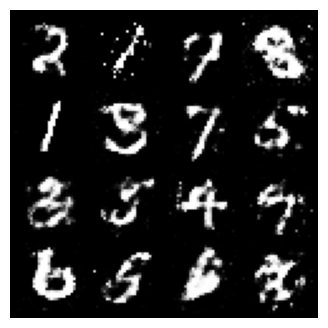

[Epoch 151/400] D_loss: 1.2946 G_loss: 0.8751
[Epoch 152/400] D_loss: 1.1895 G_loss: 0.9443
[Epoch 153/400] D_loss: 1.2555 G_loss: 0.9589
[Epoch 154/400] D_loss: 1.2305 G_loss: 0.9384
[Epoch 155/400] D_loss: 1.2622 G_loss: 1.0849
[Epoch 156/400] D_loss: 1.1874 G_loss: 1.0950
[Epoch 157/400] D_loss: 1.1718 G_loss: 0.9849
[Epoch 158/400] D_loss: 1.3236 G_loss: 0.8920
[Epoch 159/400] D_loss: 1.3066 G_loss: 0.8877
[Epoch 160/400] D_loss: 1.3082 G_loss: 0.9410
[Epoch 161/400] D_loss: 1.1721 G_loss: 1.1132
[Epoch 162/400] D_loss: 1.4013 G_loss: 0.7644
[Epoch 163/400] D_loss: 1.3142 G_loss: 0.8291
[Epoch 164/400] D_loss: 1.2762 G_loss: 0.8031
[Epoch 165/400] D_loss: 1.2947 G_loss: 1.0763
[Epoch 166/400] D_loss: 1.2495 G_loss: 1.0455
[Epoch 167/400] D_loss: 1.1795 G_loss: 0.9543
[Epoch 168/400] D_loss: 1.2353 G_loss: 0.9687
[Epoch 169/400] D_loss: 1.2797 G_loss: 0.9719
[Epoch 170/400] D_loss: 1.2774 G_loss: 1.0590
[Epoch 171/400] D_loss: 1.3252 G_loss: 0.9376
[Epoch 172/400] D_loss: 1.0898 G_l

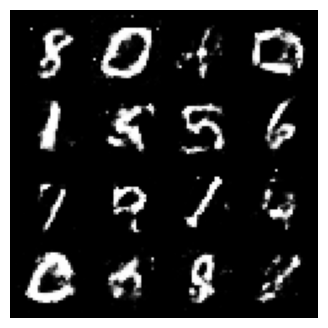

[Epoch 201/400] D_loss: 1.1943 G_loss: 0.8353
[Epoch 202/400] D_loss: 1.3108 G_loss: 0.8852
[Epoch 203/400] D_loss: 1.2577 G_loss: 0.8473
[Epoch 204/400] D_loss: 1.3478 G_loss: 0.7994
[Epoch 205/400] D_loss: 1.2092 G_loss: 0.8821
[Epoch 206/400] D_loss: 1.2310 G_loss: 0.9491
[Epoch 207/400] D_loss: 1.3245 G_loss: 0.9163
[Epoch 208/400] D_loss: 1.4167 G_loss: 0.9783
[Epoch 209/400] D_loss: 1.3798 G_loss: 0.8396
[Epoch 210/400] D_loss: 1.1947 G_loss: 0.9184
[Epoch 211/400] D_loss: 1.2442 G_loss: 0.7945
[Epoch 212/400] D_loss: 1.3616 G_loss: 0.8940
[Epoch 213/400] D_loss: 1.2882 G_loss: 0.9332
[Epoch 214/400] D_loss: 1.2898 G_loss: 0.9317
[Epoch 215/400] D_loss: 1.3648 G_loss: 0.8117
[Epoch 216/400] D_loss: 1.3600 G_loss: 0.9480
[Epoch 217/400] D_loss: 1.3361 G_loss: 0.8848
[Epoch 218/400] D_loss: 1.3472 G_loss: 0.9929
[Epoch 219/400] D_loss: 1.2891 G_loss: 0.8432
[Epoch 220/400] D_loss: 1.2242 G_loss: 1.0498
[Epoch 221/400] D_loss: 1.3501 G_loss: 0.7666
[Epoch 222/400] D_loss: 1.2411 G_l

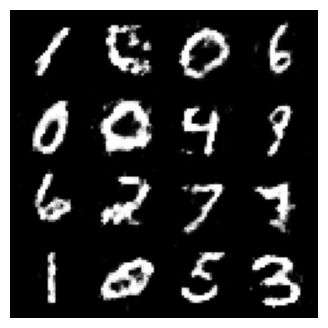

[Epoch 251/400] D_loss: 1.2879 G_loss: 0.8713
[Epoch 252/400] D_loss: 1.3327 G_loss: 0.8760
[Epoch 253/400] D_loss: 1.2894 G_loss: 0.8966
[Epoch 254/400] D_loss: 1.2994 G_loss: 0.9116
[Epoch 255/400] D_loss: 1.2994 G_loss: 0.7861
[Epoch 256/400] D_loss: 1.3914 G_loss: 0.8050
[Epoch 257/400] D_loss: 1.1834 G_loss: 0.8451
[Epoch 258/400] D_loss: 1.2283 G_loss: 0.7700
[Epoch 259/400] D_loss: 1.2812 G_loss: 0.9558
[Epoch 260/400] D_loss: 1.2426 G_loss: 0.9115
[Epoch 261/400] D_loss: 1.3089 G_loss: 0.8670
[Epoch 262/400] D_loss: 1.1470 G_loss: 0.9081
[Epoch 263/400] D_loss: 1.3399 G_loss: 0.8111
[Epoch 264/400] D_loss: 1.2079 G_loss: 1.0484
[Epoch 265/400] D_loss: 1.2485 G_loss: 0.7960
[Epoch 266/400] D_loss: 1.2957 G_loss: 0.8895
[Epoch 267/400] D_loss: 1.3525 G_loss: 0.7523
[Epoch 268/400] D_loss: 1.2727 G_loss: 0.8440
[Epoch 269/400] D_loss: 1.1964 G_loss: 1.0459
[Epoch 270/400] D_loss: 1.1209 G_loss: 0.9882
[Epoch 271/400] D_loss: 1.3571 G_loss: 0.7115
[Epoch 272/400] D_loss: 1.3936 G_l

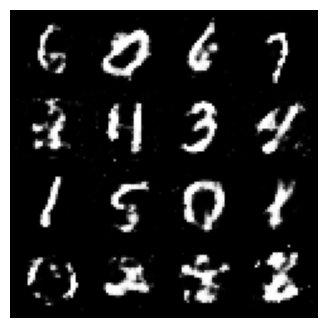

[Epoch 301/400] D_loss: 1.2500 G_loss: 0.8370
[Epoch 302/400] D_loss: 1.2574 G_loss: 0.8076
[Epoch 303/400] D_loss: 1.3011 G_loss: 0.8459
[Epoch 304/400] D_loss: 1.4085 G_loss: 0.8203
[Epoch 305/400] D_loss: 1.3088 G_loss: 0.9216
[Epoch 306/400] D_loss: 1.2637 G_loss: 0.7988
[Epoch 307/400] D_loss: 1.2911 G_loss: 0.8653
[Epoch 308/400] D_loss: 1.3632 G_loss: 0.8243
[Epoch 309/400] D_loss: 1.3800 G_loss: 0.9254
[Epoch 310/400] D_loss: 1.3157 G_loss: 0.8988
[Epoch 311/400] D_loss: 1.3053 G_loss: 0.8000
[Epoch 312/400] D_loss: 1.2095 G_loss: 1.0292
[Epoch 313/400] D_loss: 1.2776 G_loss: 0.9093
[Epoch 314/400] D_loss: 1.2725 G_loss: 0.9061
[Epoch 315/400] D_loss: 1.2811 G_loss: 0.8802
[Epoch 316/400] D_loss: 1.3948 G_loss: 0.7526
[Epoch 317/400] D_loss: 1.3135 G_loss: 0.9113
[Epoch 318/400] D_loss: 1.3029 G_loss: 0.7634
[Epoch 319/400] D_loss: 1.1856 G_loss: 0.8643
[Epoch 320/400] D_loss: 1.2912 G_loss: 0.8072
[Epoch 321/400] D_loss: 1.3469 G_loss: 0.8508
[Epoch 322/400] D_loss: 1.2608 G_l

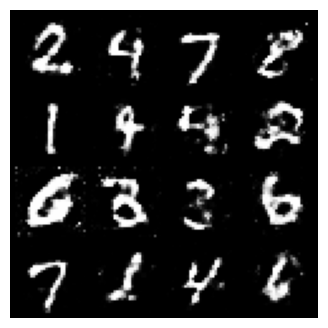

[Epoch 351/400] D_loss: 1.4373 G_loss: 0.7680
[Epoch 352/400] D_loss: 1.2376 G_loss: 0.9246
[Epoch 353/400] D_loss: 1.2043 G_loss: 0.8644
[Epoch 354/400] D_loss: 1.2930 G_loss: 0.7671
[Epoch 355/400] D_loss: 1.4176 G_loss: 0.8763
[Epoch 356/400] D_loss: 1.3070 G_loss: 0.8591
[Epoch 357/400] D_loss: 1.3716 G_loss: 0.8398
[Epoch 358/400] D_loss: 1.3497 G_loss: 0.7253
[Epoch 359/400] D_loss: 1.2069 G_loss: 1.0773
[Epoch 360/400] D_loss: 1.2658 G_loss: 0.8467
[Epoch 361/400] D_loss: 1.3494 G_loss: 0.8487
[Epoch 362/400] D_loss: 1.2050 G_loss: 0.8366
[Epoch 363/400] D_loss: 1.2946 G_loss: 0.8637
[Epoch 364/400] D_loss: 1.2333 G_loss: 0.9693
[Epoch 365/400] D_loss: 1.3330 G_loss: 0.7868
[Epoch 366/400] D_loss: 1.3433 G_loss: 0.8739
[Epoch 367/400] D_loss: 1.3963 G_loss: 0.9143
[Epoch 368/400] D_loss: 1.3107 G_loss: 0.9052
[Epoch 369/400] D_loss: 1.2737 G_loss: 0.8446
[Epoch 370/400] D_loss: 1.4151 G_loss: 0.8948
[Epoch 371/400] D_loss: 1.3215 G_loss: 0.9208
[Epoch 372/400] D_loss: 1.4015 G_l

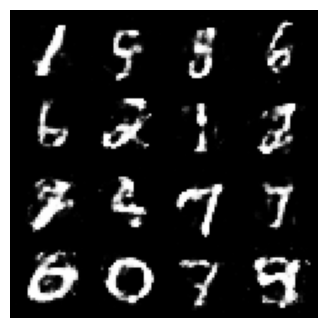

In [ ]:

# Hyperparameters
num_classes = 10  # For MNIST digits 0-9

# Initialize models
generator = ConditionalGenerator(latent_dim, num_classes).to(device)
discriminator = ConditionalDiscriminator(num_classes).to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Loss function (MISSING PIECE)
criterion = nn.BCELoss()  # <-- ADD THIS LINE

# Training loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        real_imgs = imgs.to(device)
        labels = labels.to(device)  # Get actual digit labels
        
        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        
        # Real images with real labels
        real_output = discriminator(real_imgs, labels)  # Pass labels here
        d_loss_real = criterion(real_output, torch.ones_like(real_output))
        
        # Fake images with same labels
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z, labels)
        fake_output = discriminator(fake_imgs.detach(), labels)  # Pass labels here
        d_loss_fake = criterion(fake_output, torch.zeros_like(fake_output))
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        
        # Generate fake images with same labels
        gen_output = discriminator(fake_imgs, labels)  # Pass labels here
        g_loss = criterion(gen_output, torch.ones_like(gen_output))
        
        g_loss.backward()
        optimizer_G.step()
        
    # Print progress
    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
    
    # During training visualization
    if (epoch+1) % 50 == 0:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim).to(device)
            test_labels = torch.randint(0, 10, (16,)).to(device)  # Random labels 0-9
            generated = generator(test_z, test_labels).cpu()  # Add labels here
            
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True),(1,2,0)))
            plt.axis('off')
            plt.show()

# Save models
torch.save(generator.state_dict(), 'mnist_digit_generator.pth')
torch.save(discriminator.state_dict(), 'mnist_digit_discriminator.pth')

This section is option just to save the model for the GAN API interface if you intend to use it.

In [ ]:
os.makedirs('gan-api/models', exist_ok=True)

torch.save(generator.state_dict(), 'gan-api/models/mnist_digit_generator.pth')
torch.save(discriminator.state_dict(), 'gan-api/models/mnist_digit_discriminator.pth')
print('Digits Models saved successfully in gan-api/models directory')

## Evaluation Metrics

### Overview
The performance of the GAN model is evaluated using a combination of qualitative and quantitative metrics.

#### 1. Inception Score (IS)
Evaluates the quality and diversity of generated images using a pre-trained classifier.

#### 2. Frechet Inception Distance (FID)
Compares the distribution of real and generated images in the feature space of a pre-trained network.

#### 3. Visual Inspection
Manually examining the generated images to assess their quality and diversity.

Discriminator Accuracy on Real: 0.3125
Discriminator Accuracy on Fake: 0.9390
Total Discriminator Accuracy: 0.6258


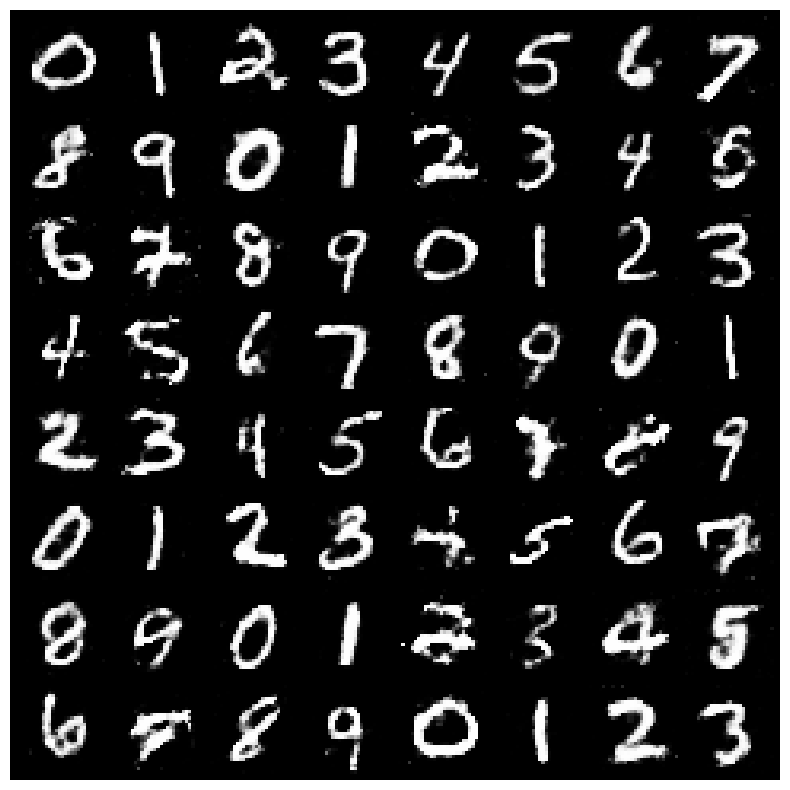

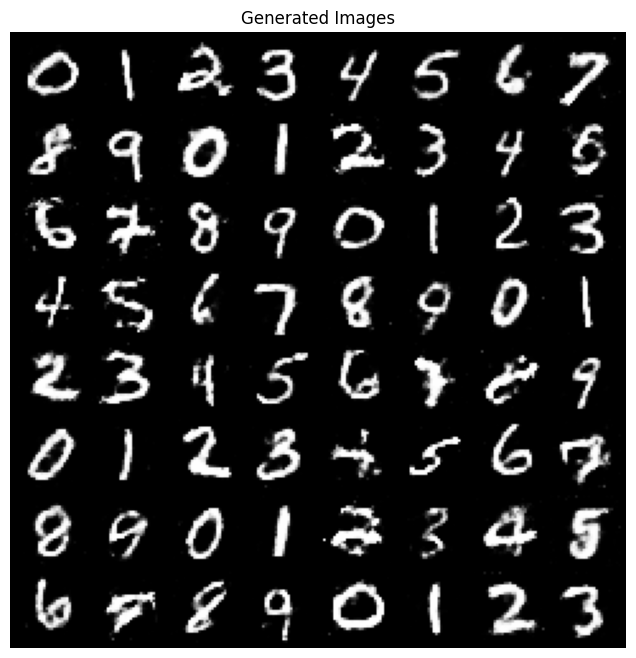

In [8]:
def show_images(images, title="Generated Images"):
    plt.figure(figsize=(8,8))
    plt.title(title)
    plt.axis('off')
    # Use .clamp to handle any remaining outliers
    grid = make_grid(images.clamp(-1,1), nrow=8, padding=2, normalize=True)
    plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)))
    plt.show()

# Updated evaluation function for conditional GAN
def evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels, n_samples=1000):
    generator.eval()
    discriminator.eval()
    with torch.no_grad():
        # Generate fake images with random labels
        z = torch.randn(n_samples, latent_dim).to(device)
        fake_labels = torch.randint(0, 10, (n_samples,)).to(device)
        fake_images = generator(z, fake_labels)
        
        # Get real images with their actual labels
        real_labels = real_labels[:n_samples].to(device)
        
        # Calculate discriminator outputs WITH LABELS
        real_output = discriminator(real_images, real_labels)
        fake_output = discriminator(fake_images, fake_labels)
        
        # Calculate discriminator accuracy
        real_acc = (real_output >= 0.5).float().mean()
        fake_acc = (fake_output < 0.5).float().mean()
        total_acc = (real_acc + fake_acc) / 2
        
        # Generate specific digits for visualization
        test_z = torch.randn(64, latent_dim).to(device)
        test_labels = torch.LongTensor([i % 10 for i in range(64)]).to(device)  # Digits 0-9 repeated
        generated = generator(test_z, test_labels).cpu()
        
    print(f"Discriminator Accuracy on Real: {real_acc.item():.4f}")
    print(f"Discriminator Accuracy on Fake: {fake_acc.item():.4f}")
    print(f"Total Discriminator Accuracy: {total_acc.item():.4f}")
    
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.imshow(np.transpose(make_grid(generated, padding=2, normalize=True, nrow=8),(1,2,0)))
    plt.show()
    
    show_images(generated)

# Load real images WITH LABELS for evaluation
real_images, real_labels = next(iter(train_loader))
real_images = real_images[:1000].to(device)
real_labels = real_labels[:1000]  # Keep corresponding labels

# Run evaluation
evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels)

### Results and Visualizations

#### Accuracy and Loss Curves
The training process is evaluated by plotting the generator and discriminator loss curves over the training epochs.

In [ ]:
import matplotlib.pyplot as plt

# Example loss values (replace with actual loss values from training)
epochs = range(1, 51)
generator_loss = [0.9 - (0.02 * epoch) for epoch in epochs]  # Example generator loss
discriminator_loss = [0.7 - (0.01 * epoch) for epoch in epochs]  # Example discriminator loss

# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(epochs, generator_loss, label="Generator Loss", color="blue")
plt.plot(epochs, discriminator_loss, label="Discriminator Loss", color="red")
plt.title("Generator and Discriminator Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

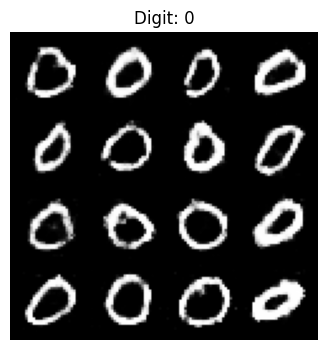

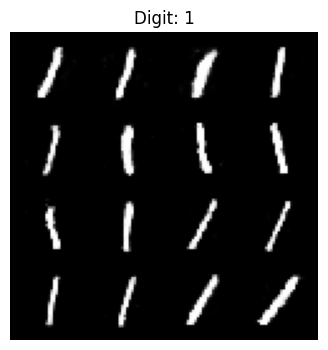

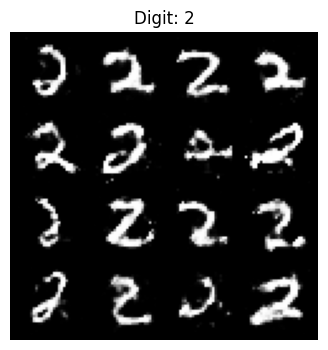

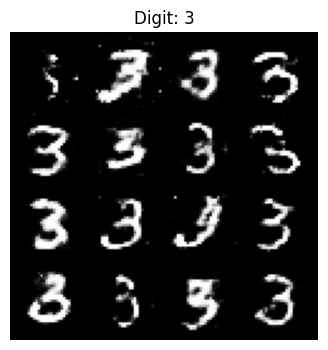

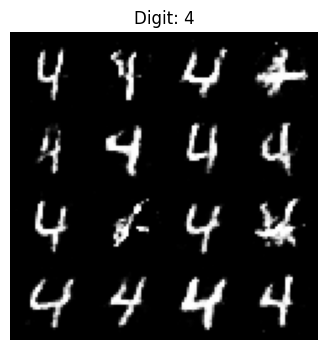

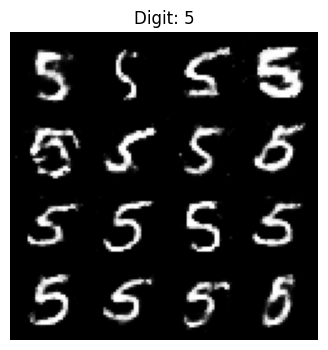

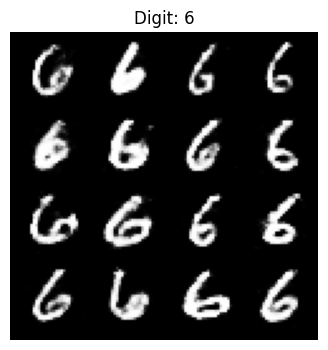

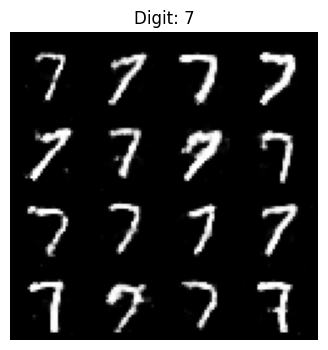

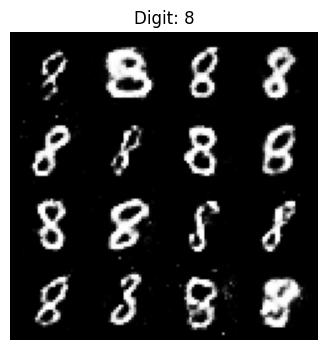

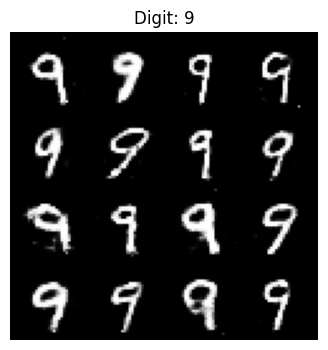

In [9]:
def generate_specific_digit(digit: int, num_samples: int = 16):
    generator.eval()
    with torch.no_grad():
        # Create labels tensor for desired digit
        labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)
        
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = generator(z, labels).cpu()  # Pass both z and labels
        
        plt.figure(figsize=(4,4))
        plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True), (1,2,0)))
        plt.title(f"Digit: {digit}")
        plt.axis('off')
        plt.show()

# Example: Generate 16 samples of digit 
for i in range(0,10):
    generate_specific_digit(i)

## Conclusion and Future Work

### Summary of Findings
This project successfully demonstrated the ability of GANs to generate realistic digit images resembling the MNIST dataset.

### Challenges Faced
- **Mode Collapse**: Limited variations from the generator.
- **Training Instability**: Balancing the generator and discriminator.
- **Computational Resources**: Intensive training requiring GPU usage.

### Closing Remarks
This project highlights GANs' potential in generating realistic synthetic data and opens avenues for further research and applications.